In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

In [2]:
np.random.seed(42)

data = {
    "LIMIT_BAL": np.random.randint(10000, 500000, 1000),
    "SEX": np.random.randint(1, 3, 1000),
    "EDUCATION": np.random.randint(1, 4, 1000),
    "MARRIAGE": np.random.randint(1, 3, 1000),
    "AGE": np.random.randint(21, 60, 1000),

    "PAY_0": np.random.randint(-1, 4, 1000),
    "PAY_2": np.random.randint(-1, 4, 1000),
    "PAY_3": np.random.randint(-1, 4, 1000),
    "PAY_4": np.random.randint(-1, 4, 1000),
    "PAY_5": np.random.randint(-1, 4, 1000),
    "PAY_6": np.random.randint(-1, 4, 1000),

    "BILL_AMT1": np.random.randint(0, 200000, 1000),
    "BILL_AMT2": np.random.randint(0, 200000, 1000),
    "BILL_AMT3": np.random.randint(0, 200000, 1000),
    "BILL_AMT4": np.random.randint(0, 200000, 1000),
    "BILL_AMT5": np.random.randint(0, 200000, 1000),
    "BILL_AMT6": np.random.randint(0, 200000, 1000),

    "PAY_AMT1": np.random.randint(0, 50000, 1000),
    "PAY_AMT2": np.random.randint(0, 50000, 1000),
    "PAY_AMT3": np.random.randint(0, 50000, 1000),
    "PAY_AMT4": np.random.randint(0, 50000, 1000),
    "PAY_AMT5": np.random.randint(0, 50000, 1000),
    "PAY_AMT6": np.random.randint(0, 50000, 1000),

    "default.payment.next.month": np.random.randint(0, 2, 1000)
}

df = pd.DataFrame(data)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,131958,2,2,1,26,-1,1,0,1,3,...,93878,3447,193516,26558,8752,26547,16489,21513,27105,1
1,156867,1,3,1,47,3,-1,2,3,0,...,125407,184215,97158,43188,13440,28936,11745,4403,46871,1
2,141932,2,2,2,43,2,1,3,2,0,...,116869,193978,138955,13012,44864,20287,5818,4897,20990,1
3,375838,2,3,1,47,1,1,-1,1,1,...,21395,10662,150780,33236,49691,41351,42654,163,25499,1
4,269178,1,1,1,54,3,2,1,1,0,...,185254,194073,46221,38673,6499,25476,33149,36078,6421,1


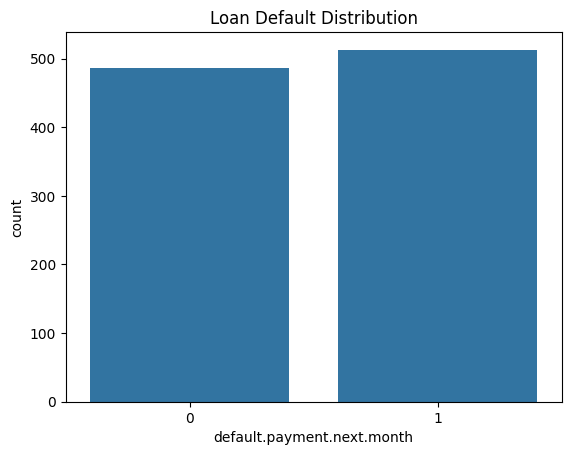

In [3]:
sns.countplot(x="default.payment.next.month", data=df)
plt.title("Loan Default Distribution")
plt.show()

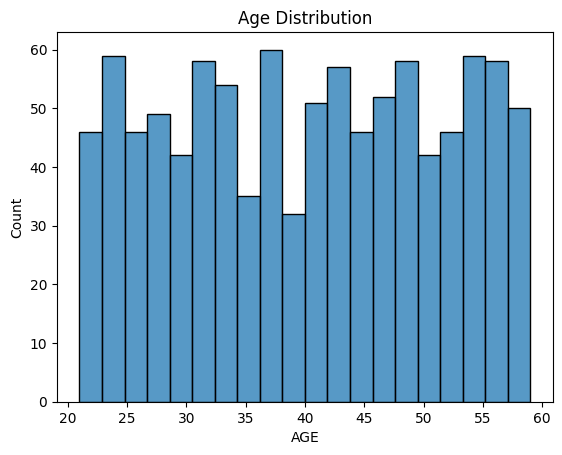

In [4]:
sns.histplot(df["AGE"], bins=20)
plt.title("Age Distribution")
plt.show()

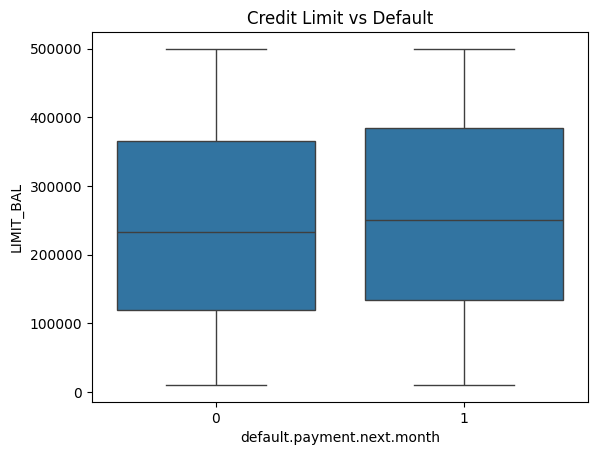

In [5]:
sns.boxplot(x="default.payment.next.month", y="LIMIT_BAL", data=df)
plt.title("Credit Limit vs Default")
plt.show()

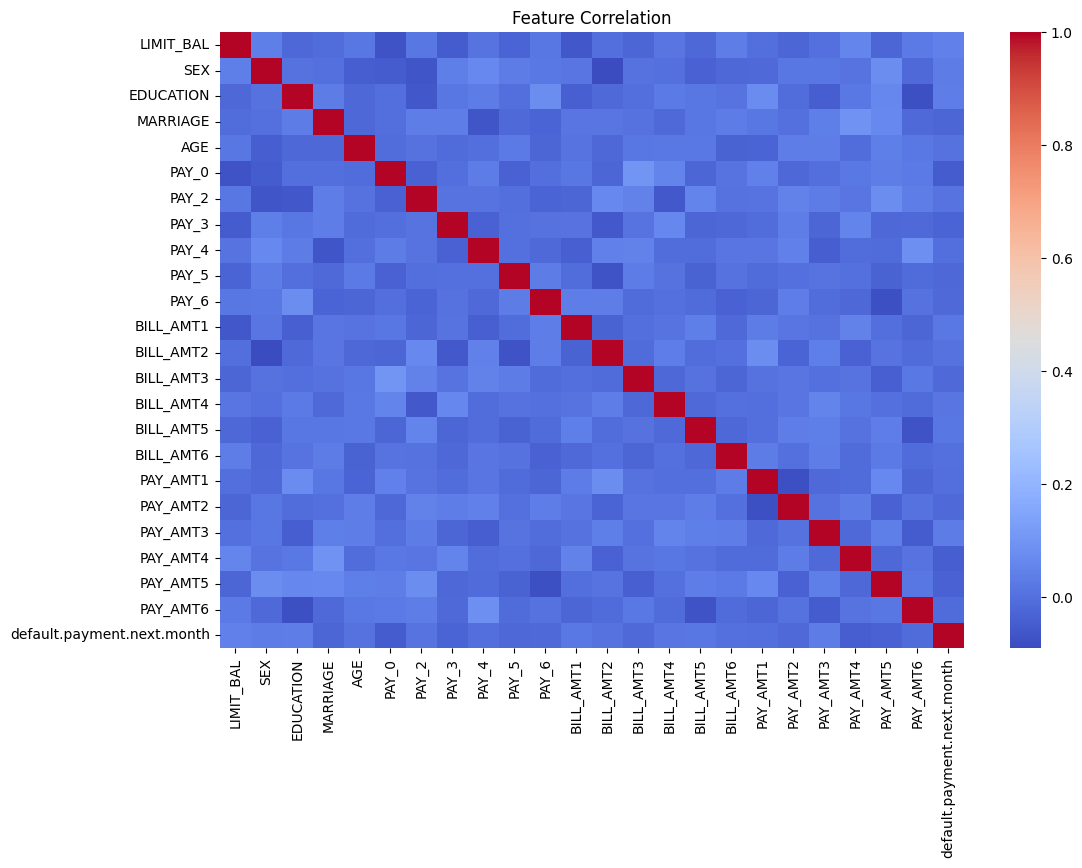

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [8]:
X = df.drop("default.payment.next.month", axis=1)

y = df["default.payment.next.month"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.45


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.39      0.41        98
           1       0.46      0.51      0.49       102

    accuracy                           0.45       200
   macro avg       0.45      0.45      0.45       200
weighted avg       0.45      0.45      0.45       200



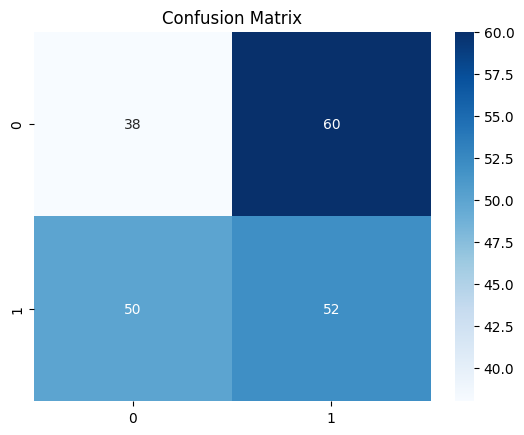

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [17]:
sample_input = np.array([[

200000,  # LIMIT_BAL
1,       # SEX
2,       # EDUCATION
1,       # MARRIAGE
30,      # AGE

0,0,0,0,0,0,   # PAY_0 to PAY_6

5000,4000,3000,2000,1000,500,  # BILL_AMT

2000,1500,1000,800,500,300     # PAY_AMT

]])

In [18]:
sample_scaled = scaler.transform(sample_input)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)

print("Prediction:", prediction)

print("Default Probability:", probability)

Prediction: [0]
Default Probability: [[0.54 0.46]]


In [20]:
risk_score = probability[0][1]

print("Risk Score:", risk_score)

if risk_score < 0.4:
    print("Loan Approved")
else:
    print("Loan Rejected")

Risk Score: 0.46
Loan Rejected
